Dataset loaded successfully. Shape: (18829, 107)
Numerical columns: Index(['age', 'height_cm', 'weight_kg', 'nationality', 'league_rank',
       'overall', 'potential', 'value_eur', 'wage_eur', 'preferred_foot',
       ...
       '#Playmaker', '#Poacher', '#Speedster', '#Strength', '#Tackling',
       '#Tactician', 'num_traits', 'Atk_effort', 'Def_effort',
       'player_versatility'],
      dtype='object', length=101)
Categorical columns: Index(['real_face', 'Att_position', 'Def_position', 'Mid_position',
       'RES_position', 'SUB_position'],
      dtype='object')
Column value_eur contains infinities or NaNs. Handling...
Column wage_eur contains infinities or NaNs. Handling...
Column release_clause_eur contains infinities or NaNs. Handling...
Column pace contains infinities or NaNs. Handling...
Column shooting contains infinities or NaNs. Handling...
Column passing contains infinities or NaNs. Handling...
Column dribbling contains infinities or NaNs. Handling...
Column defending con

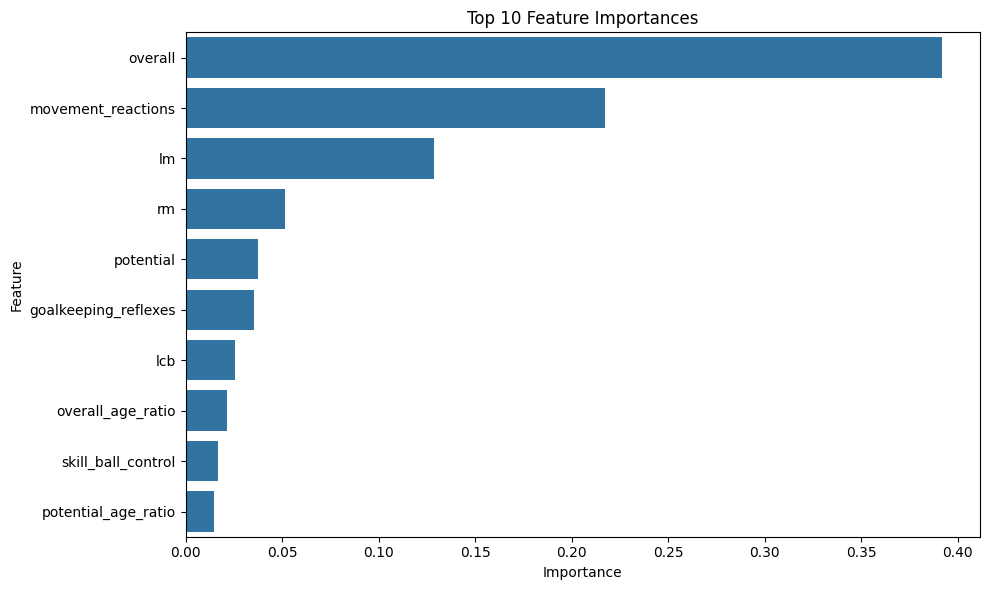

Model saved as 'xgboost_fifa_model_v3.json'.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('cleaned_data_field_2.csv')
print("Dataset loaded successfully. Shape:", df.shape)

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# Handle missing values and infinities
for col in numerical_cols:
    if np.any(np.isinf(df[col])) or np.any(df[col].isna()):
        print(f"Column {col} contains infinities or NaNs. Handling...")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("Missing values and infinities handled.")

# Drop leakage-prone columns
drop_cols = ['release_clause_eur', 'wage_eur']
df = df.drop([col for col in drop_cols if col in df.columns], axis=1)
print("Dropped columns:", drop_cols)

# Feature engineering
df['overall_age_ratio'] = df['overall'] / (df['age'] + 1)
df['skill_movement'] = df['skill_dribbling'] * df['movement_agility']
df['potential_age_ratio'] = df['potential'] / (df['age'] + 1)
df['pace_dribbling'] = df['pace'] * df['skill_dribbling']
df['overall'] = df['overall'].clip(upper=df['overall'].quantile(0.95))
print("Feature engineering completed.")

# Check correlations with target
if 'value_eur' in df.columns:
    correlations = df.select_dtypes(include=['int64', 'float64']).corr()['value_eur'].abs().sort_values(ascending=False)
    print("\nTop 5 features correlated with value_eur:")
    print(correlations.head(6))
else:
    print("Error: 'value_eur' column not found in dataset.")
    exit(1)

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
print("Categorical variables encoded.")

# Define features and target
if 'value_eur' in df.columns:
    X = df.drop('value_eur', axis=1)
    y = df['value_eur']
else:
    print("Error: 'value_eur' column not found in dataset.")
    exit(1)

# Log-transform the target
y = np.log1p(y)
print("Target variable log-transformed.")

# Verify data before scaling
if np.any(np.isinf(X)) or np.any(X.isna()):
    print("Error: Features contain infinities or NaNs after preprocessing.")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    print("Infinities and NaNs fixed.")

# Scale features
scaler = StandardScaler()
try:
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    print("Features scaled successfully.")
except Exception as e:
    print(f"Error scaling features: {e}")
    exit(1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets. X_train shape:", X_train.shape)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'reg_lambda': [50, 100, 200],
    'reg_alpha': [5, 10, 20],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R² score:", grid_search.best_score_)

# Train final model with best parameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
print("Model trained with best parameters successfully.")

# Cross-validation
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='r2')
print("Cross-validation R² scores:", cv_scores)
print("Mean CV R² score:", cv_scores.mean())
print("Standard deviation of CV scores:", cv_scores.std())

# Make predictions
y_pred = best_model.predict(X_test)
print("Predictions made successfully. y_pred shape:", y_pred.shape)

# Reverse log-transformation
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)
print("Log-transformation reversed for evaluation.")

# Evaluate the model
train_pred = best_model.predict(X_train)
train_pred_exp = np.expm1(train_pred)
y_train_exp = np.expm1(y_train)
train_rmse = np.sqrt(mean_squared_error(y_train_exp, train_pred_exp))
test_rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
train_r2 = r2_score(y_train_exp, train_pred_exp)
test_r2 = r2_score(y_test_exp, y_pred_exp)
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Training R²: {train_r2:.2f}")
print(f"Test R²: {test_r2:.2f}")

# Feature importance
feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("\nTop 5 Most Important Features:")
print(importance_df.head())

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Save the model
#best_model.save_model('xgboost_fifa_model_v3.json')
#print("Model saved as 'xgboost_fifa_model_v3.json'.")